In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    roc_auc_score,
)
from sklearn.preprocessing import label_binarize

## Predicted data

We used Gemini 3 as the predictor.

In [11]:
predictions_df = pd.read_csv('gemini_3_pilot_predictions.csv')
predictions_df

,description_A,description_B,final_label,predictor_label
0,The Nikon ACULON A211 10–22x50 zoom binoculars...,"Available exclusively to selected customers, t...",Down,B
1,This bundle includes the Kowa Sporting Optics ...,These binoculars deliver 20x magnification wit...,Down,B
2,"This full-size binocular, the most popular cho...",The Nikon ACULON A211 10–22x50 zoom binoculars...,Up,A
3,The Nikon ACULON A211 10–22x50 zoom binoculars...,"These binoculars feature a nitrogen-filled, O-...",Up,A
4,"These binoculars, the most popular choice amon...",The ICFPWR compact binoculars feature 10x magn...,Same,Uncertain
...,...,...,...,...
95,This bundle includes the Kowa Sporting Optics ...,These binoculars feature 20× magnification wit...,Same,Uncertain
96,These binoculars are the most popular choice a...,These binoculars deliver 20x magnification wit...,Down,B
97,"These binoculars feature a nitrogen-filled, O-...","Available exclusively to selected customers, t...",Down,B
98,These binoculars are designed with a nitrogen-...,These binoculars offer 20× magnification with ...,Down,B


## Ground truth data

In [12]:
golden_df = pd.read_csv('ground_truth.csv')[['description_A', 'description_B', 'final_label', 'golden_product']] 
golden_df

,description_A,description_B,final_label,golden_product
0,The Nikon ACULON A211 10–22x50 zoom binoculars...,"Available exclusively to selected customers, t...",Down,B
1,This bundle includes the Kowa Sporting Optics ...,These binoculars deliver 20x magnification wit...,Down,B
2,"This full-size binocular, the most popular cho...",The Nikon ACULON A211 10–22x50 zoom binoculars...,Up,B
3,The Nikon ACULON A211 10–22x50 zoom binoculars...,"These binoculars feature a nitrogen-filled, O-...",Up,Uncertain
4,"These binoculars, the most popular choice amon...",The ICFPWR compact binoculars feature 10x magn...,Same,B
...,...,...,...,...
95,This bundle includes the Kowa Sporting Optics ...,These binoculars feature 20× magnification wit...,Same,B
96,These binoculars are the most popular choice a...,These binoculars deliver 20x magnification wit...,Down,Uncertain
97,"These binoculars feature a nitrogen-filled, O-...","Available exclusively to selected customers, t...",Down,Uncertain
98,These binoculars are designed with a nitrogen-...,These binoculars offer 20× magnification with ...,Down,A


# Evaluation

Labels: ['A', 'B', 'Uncertain']
N: 100
   accuracy  balanced_accuracy  macro_precision  macro_recall  macro_f1  \
0      0.16           0.203117         0.144444      0.203117  0.153187   

   weighted_precision  weighted_recall  weighted_f1  
0            0.134667             0.16     0.126282  
              precision    recall  f1-score  support
A              0.166667  0.315789  0.218182    19.00
B              0.166667  0.272727  0.206897    33.00
Uncertain      0.100000  0.020833  0.034483    48.00
accuracy       0.160000  0.160000  0.160000     0.16
macro avg      0.144444  0.203117  0.153187   100.00
weighted avg   0.134667  0.160000  0.126282   100.00
                pred_A  pred_B  pred_Uncertain
true_A               6      13               0
true_B              15       9               9
true_Uncertain      15      32               1


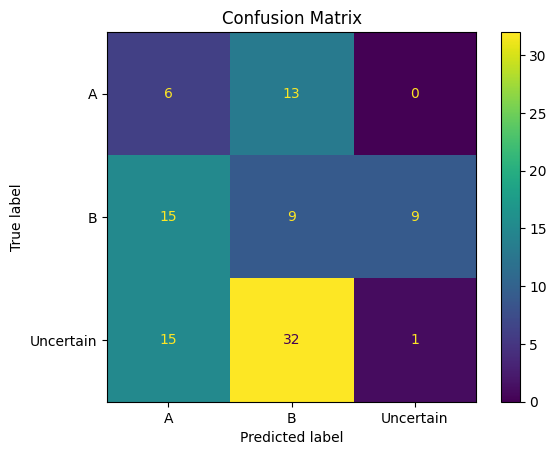

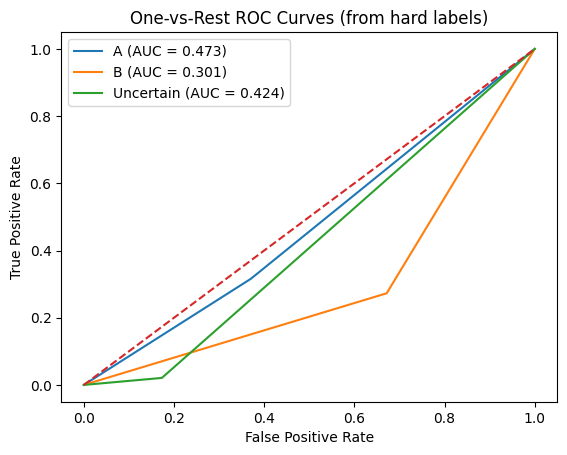

       class       auc
0          A  0.472710
1          B  0.300543
2  Uncertain  0.423878
   roc_auc_macro_ovr  roc_auc_weighted_ovr
0           0.399043              0.392455


In [13]:
# --------------------------------------------------
# inputs
# predictions_df: must contain predictor_label
# golden_df: must contain golden_product
# --------------------------------------------------

# example:
# predictions_df = pd.read_csv("predictions_df.csv")
# golden_df = pd.read_csv("golden_df.csv")

y_pred = predictions_df["predictor_label"].astype(str).str.strip()
y_true = golden_df["golden_product"].astype(str).str.strip()

# align indexes just in case
y_true = y_true.reset_index(drop=True)
y_pred = y_pred.reset_index(drop=True)

# keep only rows where both exist
valid = y_true.notna() & y_pred.notna()
y_true = y_true[valid]
y_pred = y_pred[valid]

labels = sorted(set(y_true.unique()) | set(y_pred.unique()))
print("Labels:", labels)
print("N:", len(y_true))

# --------------------------------------------------
# core metrics
# --------------------------------------------------
metrics_summary = {
    "accuracy": accuracy_score(y_true, y_pred),
    "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
    "macro_precision": precision_score(y_true, y_pred, labels=labels, average="macro", zero_division=0),
    "macro_recall": recall_score(y_true, y_pred, labels=labels, average="macro", zero_division=0),
    "macro_f1": f1_score(y_true, y_pred, labels=labels, average="macro", zero_division=0),
    "weighted_precision": precision_score(y_true, y_pred, labels=labels, average="weighted", zero_division=0),
    "weighted_recall": recall_score(y_true, y_pred, labels=labels, average="weighted", zero_division=0),
    "weighted_f1": f1_score(y_true, y_pred, labels=labels, average="weighted", zero_division=0),
}

metrics_df = pd.DataFrame([metrics_summary])
print(metrics_df)

# --------------------------------------------------
# per-class report
# --------------------------------------------------
report_dict = classification_report(
    y_true,
    y_pred,
    labels=labels,
    output_dict=True,
    zero_division=0
)
classification_report_df = pd.DataFrame(report_dict).T
print(classification_report_df)

# --------------------------------------------------
# confusion matrix
# --------------------------------------------------
cm = confusion_matrix(y_true, y_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=[f"true_{x}" for x in labels], columns=[f"pred_{x}" for x in labels])
print(cm_df)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

# --------------------------------------------------
# ROC / AUC from hard labels only
# NOTE:
# This works, but it is not very informative unless you have
# probabilities or confidence scores.
# --------------------------------------------------
y_true_bin = label_binarize(y_true, classes=labels)
y_pred_bin = label_binarize(y_pred, classes=labels)

roc_rows = []
plt.figure()

for i, label in enumerate(labels):
    # skip if a class is absent in ground truth after filtering
    if y_true_bin[:, i].sum() == 0 or y_true_bin[:, i].sum() == len(y_true_bin):
        continue

    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_bin[:, i])
    roc_auc = auc(fpr, tpr)

    roc_rows.append({
        "class": label,
        "auc": roc_auc,
    })

    plt.plot(fpr, tpr, label=f"{label} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("One-vs-Rest ROC Curves (from hard labels)")
plt.legend()
plt.show()

roc_auc_df = pd.DataFrame(roc_rows)
print(roc_auc_df)

# macro / weighted one-vs-rest ROC AUC from hard predictions
# may fail if some classes are missing entirely
try:
    roc_auc_macro_ovr = roc_auc_score(y_true_bin, y_pred_bin, average="macro", multi_class="ovr")
    roc_auc_weighted_ovr = roc_auc_score(y_true_bin, y_pred_bin, average="weighted", multi_class="ovr")
except Exception:
    roc_auc_macro_ovr = np.nan
    roc_auc_weighted_ovr = np.nan

auc_summary_df = pd.DataFrame([{
    "roc_auc_macro_ovr": roc_auc_macro_ovr,
    "roc_auc_weighted_ovr": roc_auc_weighted_ovr,
}])

print(auc_summary_df)

# --------------------------------------------------
# save outputs
# --------------------------------------------------
metrics_df.to_csv("metrics_summary.csv", index=False)
classification_report_df.to_csv("classification_report.csv")
cm_df.to_csv("confusion_matrix.csv")
roc_auc_df.to_csv("roc_auc_per_class.csv", index=False)
auc_summary_df.to_csv("roc_auc_summary.csv", index=False)